In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


In [2]:
train_dir = "../data/processed/classification_preprocessed/train"
val_dir = "../data/processed/classification_preprocessed/val"
test_dir = "../data/processed/classification_preprocessed/test"

print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)

Train directory: ../data/processed/classification_preprocessed/train
Validation directory: ../data/processed/classification_preprocessed/val
Test directory: ../data/processed/classification_preprocessed/test


In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(224, 224),
    batch_size=16,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    image_size=(224, 224),
    batch_size=16,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(224, 224),
    batch_size=16,
    shuffle=False
)

Found 465 files belonging to 6 classes.
Found 114 files belonging to 6 classes.
Found 216 files belonging to 6 classes.


In [4]:
class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['aqua', 'chitato', 'indomie', 'pepsodent', 'shampoo', 'tissue']
Number of classes: 6


In [5]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("Image minimum:", tf.reduce_min(images).numpy())
    print("Image maximum:", tf.reduce_max(images).numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Image data type: <dtype: 'float32'>
Image minimum: 0.0
Image maximum: 255.0


In [6]:
batch_size=16
image_size=(224, 224)

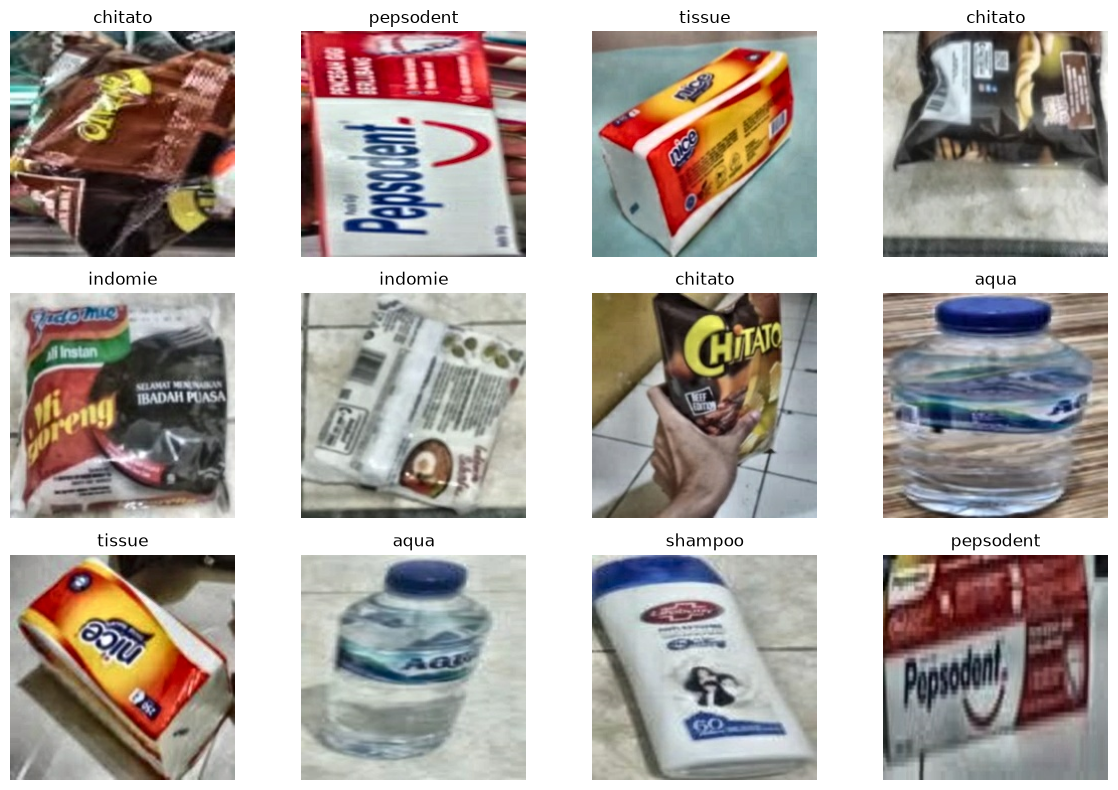

In [7]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label_index = labels[i].numpy()
        plt.title(class_names[label_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
from tensorflow.keras import layers, models

keras_model = models.Sequential([
    
    layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values from 0-255 to 0-1
    layers.Rescaling(1./255),

    # Convolution block 1
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 2
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 3
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(6, activation="softmax")
])

keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,158 (98.36 MB)

 Trainable params: 25,785,158 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [10]:
history = keras_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


c:\Users\ASUS\Desktop\Retail-CV-Intelligence\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 392ms/step - accuracy: 0.2860 - loss: 1.8904 - val_accuracy: 0.5439 - val_loss: 1.1620
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 406ms/step - accuracy: 0.6237 - loss: 1.0670 - val_accuracy: 0.7281 - val_loss: 0.7982
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 381ms/step - accuracy: 0.7591 - loss: 0.6731 - val_accuracy: 0.7018 - val_loss: 0.7961
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 382ms/step - accuracy: 0.8323 - loss: 0.4912 - val_accuracy: 0.7456 - val_loss: 0.7122
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 383ms/step - accuracy: 0.8817 - loss: 0.3998 - val_accuracy: 0.8421 - val_loss: 0.4770
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 382ms/step - accuracy: 0.8903 - loss: 0.3296 - val_accuracy: 0.8509 - val_loss: 0.5048
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 386ms/step - accuracy: 0.9484 - loss: 0.2134 - val_accuracy: 0.8509 - val_loss: 0.4951
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 384ms/step - accuracy: 0.9720 - loss: 0.0931 - val_accuracy: 0.842

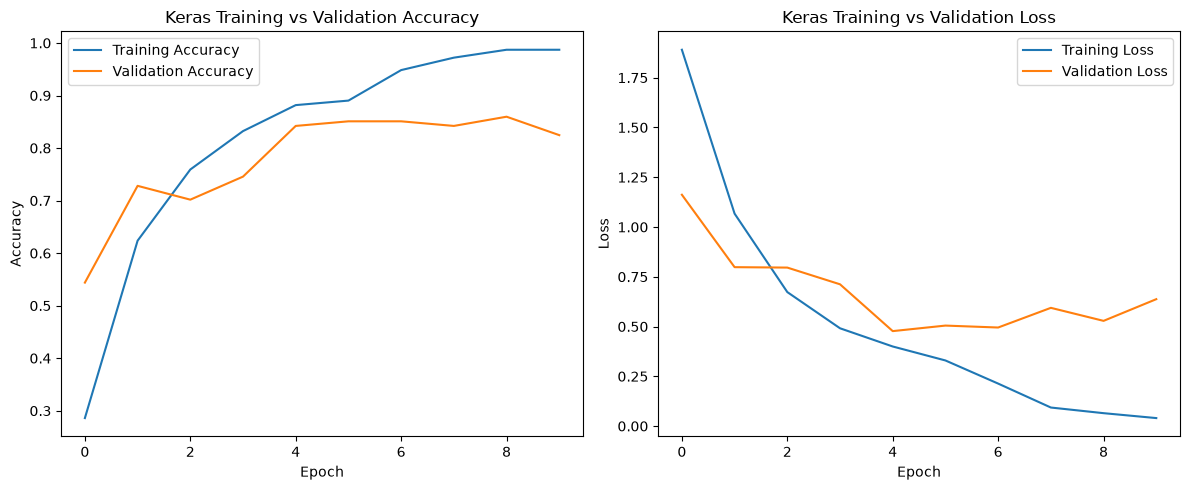

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Keras Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Keras Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
test_loss, test_accuracy = keras_model.evaluate(test_ds)

print("Keras Test Loss:", test_loss)
print("Keras Test Accuracy:", test_accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.7315 - loss: 1.1685
Keras Test Loss: 1.1685010194778442
Keras Test Accuracy: 0.7314814925193787


In [13]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = keras_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total test images:", len(y_true))
print("Total predictions:", len(y_pred))

Total test images: 216
Total predictions: 216


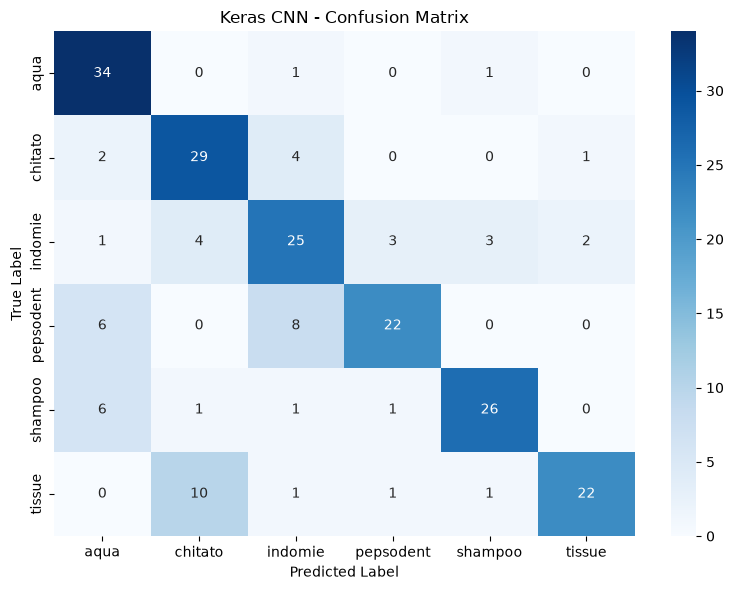

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Keras CNN - Confusion Matrix")

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

        aqua       0.69      0.94      0.80        36
     chitato       0.66      0.81      0.72        36
     indomie       0.62      0.66      0.64        38
   pepsodent       0.81      0.61      0.70        36
     shampoo       0.84      0.74      0.79        35
      tissue       0.88      0.63      0.73        35

    accuracy                           0.73       216
   macro avg       0.75      0.73      0.73       216
weighted avg       0.75      0.73      0.73       216



In [16]:
keras_model.save("../models/retail_cnn_keras.keras")

print("Keras model saved successfully.")

Keras model saved successfully.
